In [109]:
print('Radha!')

Radha!


In [110]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from pydantic import BaseModel, Field

In [111]:
load_dotenv()
model = ChatOpenAI()

In [112]:
# Structured Output Schema for cot
class EssayAnalysisForCot(BaseModel):
    cot_feedback: str = Field(
        description="Feedback on clarity of thought in the essay."
    )
    cot_score: float = Field(
        description="Score out of 10."
    )


In [113]:
cot_model = model.with_structured_output(EssayAnalysisForCot)

d:\LangGraph\venv\Lib\site-packages\langchain_openai\chat_models\base.py:2471: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


In [114]:
# Structure output schema for doa
class EssayAnalysisForDoa(BaseModel):
    doa_feedback: str = Field(
        description="Feedback on depth of analysis"
    )
    doa_score: float = Field(
        description="Score out of 10 based on depth of analysis"
    )

In [115]:

doa_model = model.with_structured_output(EssayAnalysisForDoa)

In [116]:
class SummaryOutput(BaseModel):
    overall_summary: str = Field(description="Overall summary of the essay")
    strengths: str = Field(description="Major strengths")
    weaknesses: str = Field(description="Major weaknesses")
    suggestions: str = Field(description="Suggestions for improvement")
    overall_score: float = Field(description="Average score out of 10")


In [117]:
summary_model = model.with_structured_output(SummaryOutput)

In [118]:
# Graph state
class EssayState(TypedDict):
    essay : str
    cot_feedback : str
    cot_score : float

    doa_feedback : str
    doa_score : float

    summary: str

In [119]:
def cot_response(state: EssayState):

    prompt = f"""
You are an expert essay analyst.

Analyze the following essay.

Essay:
{state['essay']}

Evaluate the essay and provide:

1. Feedback on clarity of thought.
2. A score out of 10.
"""

    result = cot_model.invoke(prompt)

    return {
        "cot_feedback": result.cot_feedback,
        "cot_score": result.cot_score,
    }


In [120]:
def doa_response(state: EssayState):
    
    prompt = f"""
You are an expert essay analyst.

Analyze the following essay.

Essay:
{state['essay']}

Evaluate the essay and provide:

1. Feedback on Detph of analysis.
2. A score out of 10.
"""

    result = doa_model.invoke(prompt)

    return {
    "doa_feedback": result.doa_feedback,
    "doa_score": result.doa_score,
}

In [121]:
def summary(state: EssayState):

    prompt = f"""
You are an expert essay evaluator.

Clarity Feedback:
{state["cot_feedback"]}

Depth of Analysis Feedback:
{state["doa_feedback"]}

Scores:
Clarity: {state["cot_score"]}
Depth: {state["doa_score"]}

Average the two scores.

Return the requested structured output.
"""

    result = summary_model.invoke(prompt)

    return {
        "overall_summary": result.overall_summary,
        "strengths": result.strengths,
        "weaknesses": result.weaknesses,
        "suggestions": result.suggestions,
        "overall_score": result.overall_score,
    }

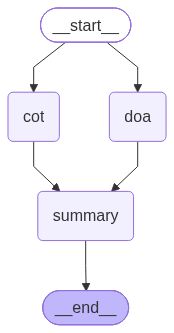

In [122]:
# create nodes 
graph = StateGraph(EssayState)
graph.add_node('cot', cot_response)
graph.add_node('doa', doa_response)
graph.add_node('summary', summary)


# add edges
graph.add_edge(START, 'cot')
graph.add_edge(START, 'doa')
graph.add_edge('cot', 'summary')
graph.add_edge('doa', 'summary')
graph.add_edge('summary', END)

graph.compile()

In [123]:
workflow = graph.compile()

intial_state = {
    'essay':''' # The Importance of Time Management

Time is one of the most valuable resources we have. Everyone has the same twenty-four hours each day, but how we use them determines our success and happiness. Good time management helps us complete tasks on schedule, reduce stress, and maintain a healthy balance between work and personal life.

Planning daily activities, setting priorities, and avoiding unnecessary distractions are simple ways to manage time effectively. Even small habits, such as creating a to-do list or finishing important tasks first, can make a significant difference.

In conclusion, time management is an essential life skill. By using our time wisely, we can achieve our goals, improve productivity, and enjoy a more organized and fulfilling life.
'''
}

In [124]:
workflow.invoke(intial_state)

{'essay': ' # The Importance of Time Management\n\nTime is one of the most valuable resources we have. Everyone has the same twenty-four hours each day, but how we use them determines our success and happiness. Good time management helps us complete tasks on schedule, reduce stress, and maintain a healthy balance between work and personal life.\n\nPlanning daily activities, setting priorities, and avoiding unnecessary distractions are simple ways to manage time effectively. Even small habits, such as creating a to-do list or finishing important tasks first, can make a significant difference.\n\nIn conclusion, time management is an essential life skill. By using our time wisely, we can achieve our goals, improve productivity, and enjoy a more organized and fulfilling life.\n',
 'cot_feedback': 'The essay effectively conveys the importance of time management and provides clear examples of how it can impact our lives. The structure of the essay is logical, with a clear introduction, body,